PASO 5: ANÁLSIS EXPLORATORIO DE DATOS.

In [3]:
#CARGAMOS LA TABLA DE NUESTRA BASE DE DATOS POSTGRESQL
import pandas as pd
import numpy as np, random
import psycopg

In [6]:

from sqlalchemy import create_engine
import configparser

config = configparser.ConfigParser()
config.read('C:/Users/Josue/4GA.DataScience/configsql.cfg')


db_config = dict(config['postgresql'])

try:
    
    conn = psycopg.connect(**db_config)
    cur = conn.cursor()

    
    cur.execute('''
        SELECT cntry, pplfair, pplhlp, ppltrst, lrscale, polintr, stfdem, stfeco, stfgov, trstep, trstlgl, trstplc, trstplt, trstprl, trstprt, trtsci_pnd, imbgeco, imwbcnt, happy, rlgdgr, cntgrp_fc, lw_pnd, cnt_fc 
        FROM "UE128k";
    ''')

   
    datos = cur.fetchall()
    columnas = [desc[0] for desc in cur.description]

    
    df_eda = pd.DataFrame(datos, columns=columnas)

    
    df_eda.info()

   
    cur.close()
    conn.close()

except psycopg.Error as e:
    print(f"Error connecting to PostgreSQL: {e}")

Error connecting to PostgreSQL: no existe la columna «trstep»
LINE 2: ...pltrst, lrscale, polintr, stfdem, stfeco, stfgov, trstep, tr...
                                                             ^


In [ ]:
#Como vemos con el info anterior, todas nuestras filas son object por lo que las pasaremos a int64 excepto la columna country que la dejaremos tal cual
def dtypetoint(df):
    for col in df.columns:
        if df[col].dtype == 'object' and col != 'cntry':
            df[col] = df[col].replace(r'[^0-9\-\.]+', np.nan, regex=True)
            df[col] = df[col].apply(lambda x: pd.to_numeric(x, errors='coerce')).astype('Int64')

    return df
dtypetoint(df_eda)
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128563 entries, 0 to 128562
Data columns (total 23 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   cntry       128563 non-null  object
 1   pplfair     128563 non-null  Int64 
 2   pplhlp      128563 non-null  Int64 
 3   ppltrst     128563 non-null  Int64 
 4   lrscale     128563 non-null  Int64 
 5   polintr     128563 non-null  Int64 
 6   stfdem      128563 non-null  Int64 
 7   stfeco      128563 non-null  Int64 
 8   stfgov      128563 non-null  Int64 
 9   trstep      128563 non-null  Int64 
 10  trstlgl     128563 non-null  Int64 
 11  trstplc     128563 non-null  Int64 
 12  trstplt     128563 non-null  Int64 
 13  trstprl     128563 non-null  Int64 
 14  trstprt     128563 non-null  Int64 
 15  trtsci_pnd  128563 non-null  Int64 
 16  imbgeco     128563 non-null  Int64 
 17  imwbcnt     128563 non-null  Int64 
 18  happy       128563 non-null  Int64 
 19  rlgdgr      128563 non-

In [ ]:
#1) Numero y tipo de variables:
def vartype(df):
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    df_tipos = pd.DataFrame({'Tipo': ['Numérica']*len(num_cols) + ['Categórica']*len(cat_cols),
                            'Columna': num_cols + cat_cols})
    total_num = len(num_cols)
    total_cat = len(cat_cols)
    total_general = total_num + total_cat
    # Crear una lista de diccionarios para las nuevas filas
    new_rows = [{'Tipo': 'Total Numérico', 'Columna': total_num},
                {'Tipo': 'Total Categórico', 'Columna': total_cat},
                {'Tipo': 'Total General', 'Columna': total_general},]
    df_tipos = pd.concat([df_tipos, pd.DataFrame(new_rows)], ignore_index=True)
    return df_tipos
print(vartype(df_eda))


                Tipo     Columna
0           Numérica     pplfair
1           Numérica      pplhlp
2           Numérica     ppltrst
3           Numérica     lrscale
4           Numérica     polintr
5           Numérica      stfdem
6           Numérica      stfeco
7           Numérica      stfgov
8           Numérica      trstep
9           Numérica     trstlgl
10          Numérica     trstplc
11          Numérica     trstplt
12          Numérica     trstprl
13          Numérica     trstprt
14          Numérica  trtsci_pnd
15          Numérica     imbgeco
16          Numérica     imwbcnt
17          Numérica       happy
18          Numérica      rlgdgr
19          Numérica   cntgrp_fc
20          Numérica      lw_pnd
21          Numérica      cnt_fc
22        Categórica       cntry
23    Total Numérico          22
24  Total Categórico           1
25     Total General          23


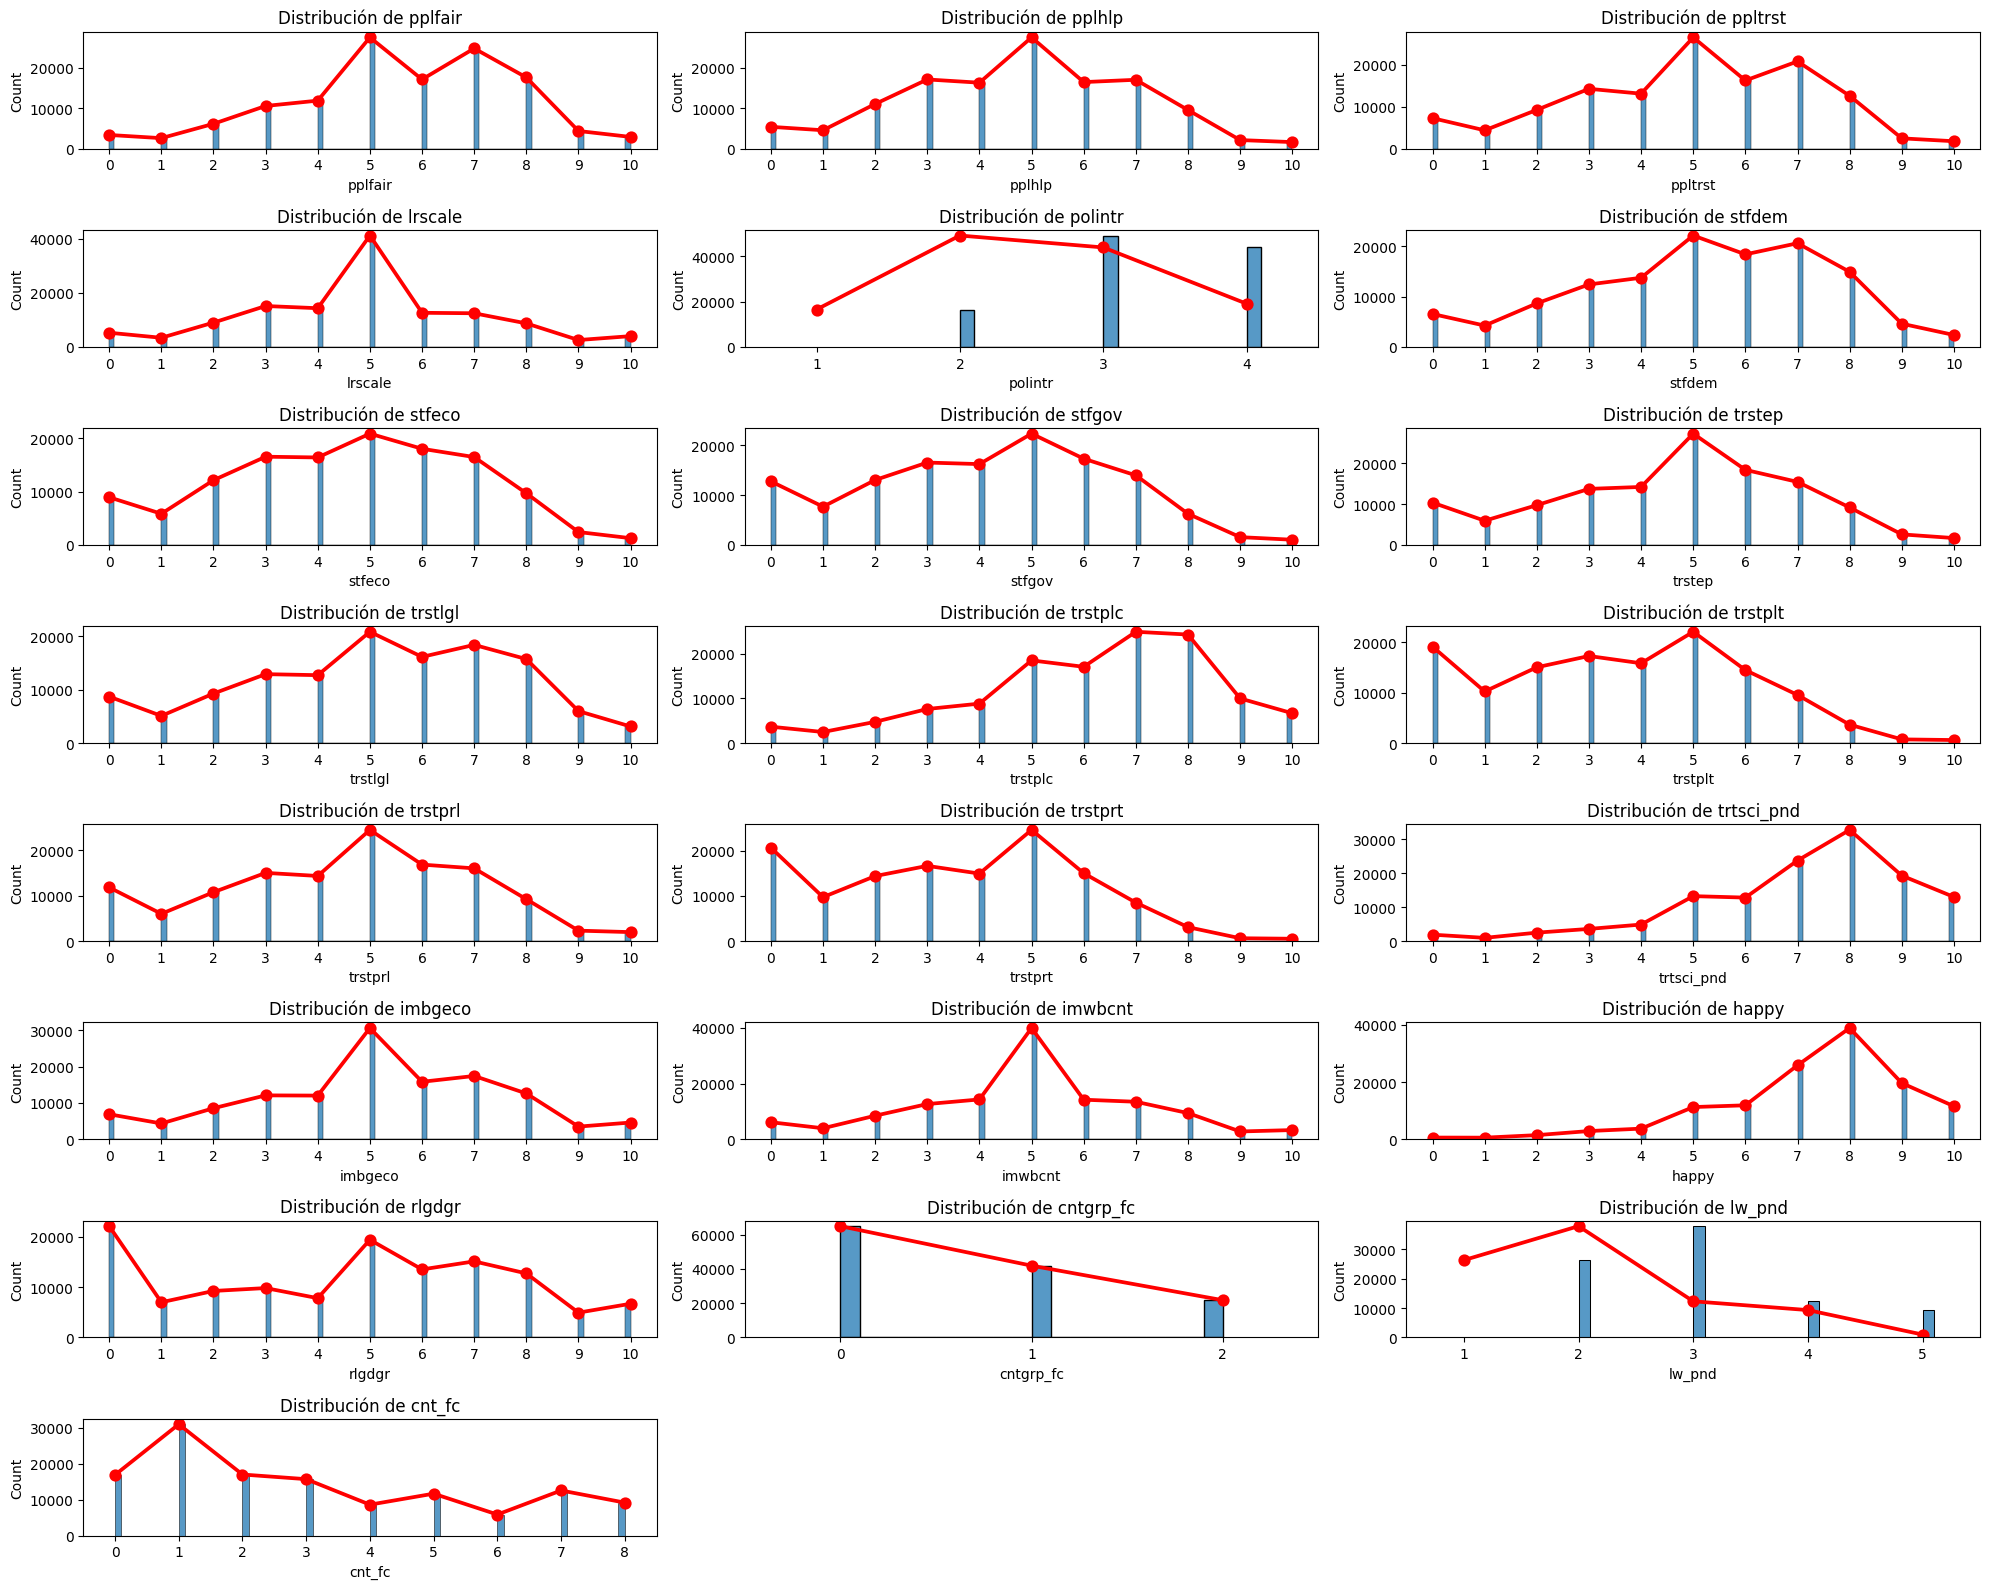

In [ ]:
#2 Analisis Univariable Númerico(Ya tenemos la unica categorica sin formato numérico factorizada).
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def uninum3(df):
    columnas_numericas = df.select_dtypes(include=['number']).columns
    num_columnas = len(columnas_numericas)
    num_filas = (num_columnas + 2) // 3  
    fig, axes = plt.subplots(num_filas, 3, figsize=(20, 2 * num_filas))
    for i, columna in enumerate(columnas_numericas):
        fila = i // 3
        columna_subplot = i % 3
        if num_filas > 1:
            ax = axes[fila, columna_subplot]
        else:
            ax = axes[columna_subplot]
        sns.histplot(df[columna], ax=ax, binwidth=0.1)  
        sns.pointplot(x=df[columna].value_counts().sort_index().index,
                      y=df[columna].value_counts().sort_index().values,
                      color='red', linestyles='-', ax=ax)
        ax.set_title(f'Distribución de {columna}')
    if num_columnas % 3 != 0 and num_filas > 1:
        for j in range(num_columnas % 3, 3):
            axes[num_filas - 1, j].set_visible(False)
    plt.tight_layout()
    plt.show()
uninum3(df_eda)

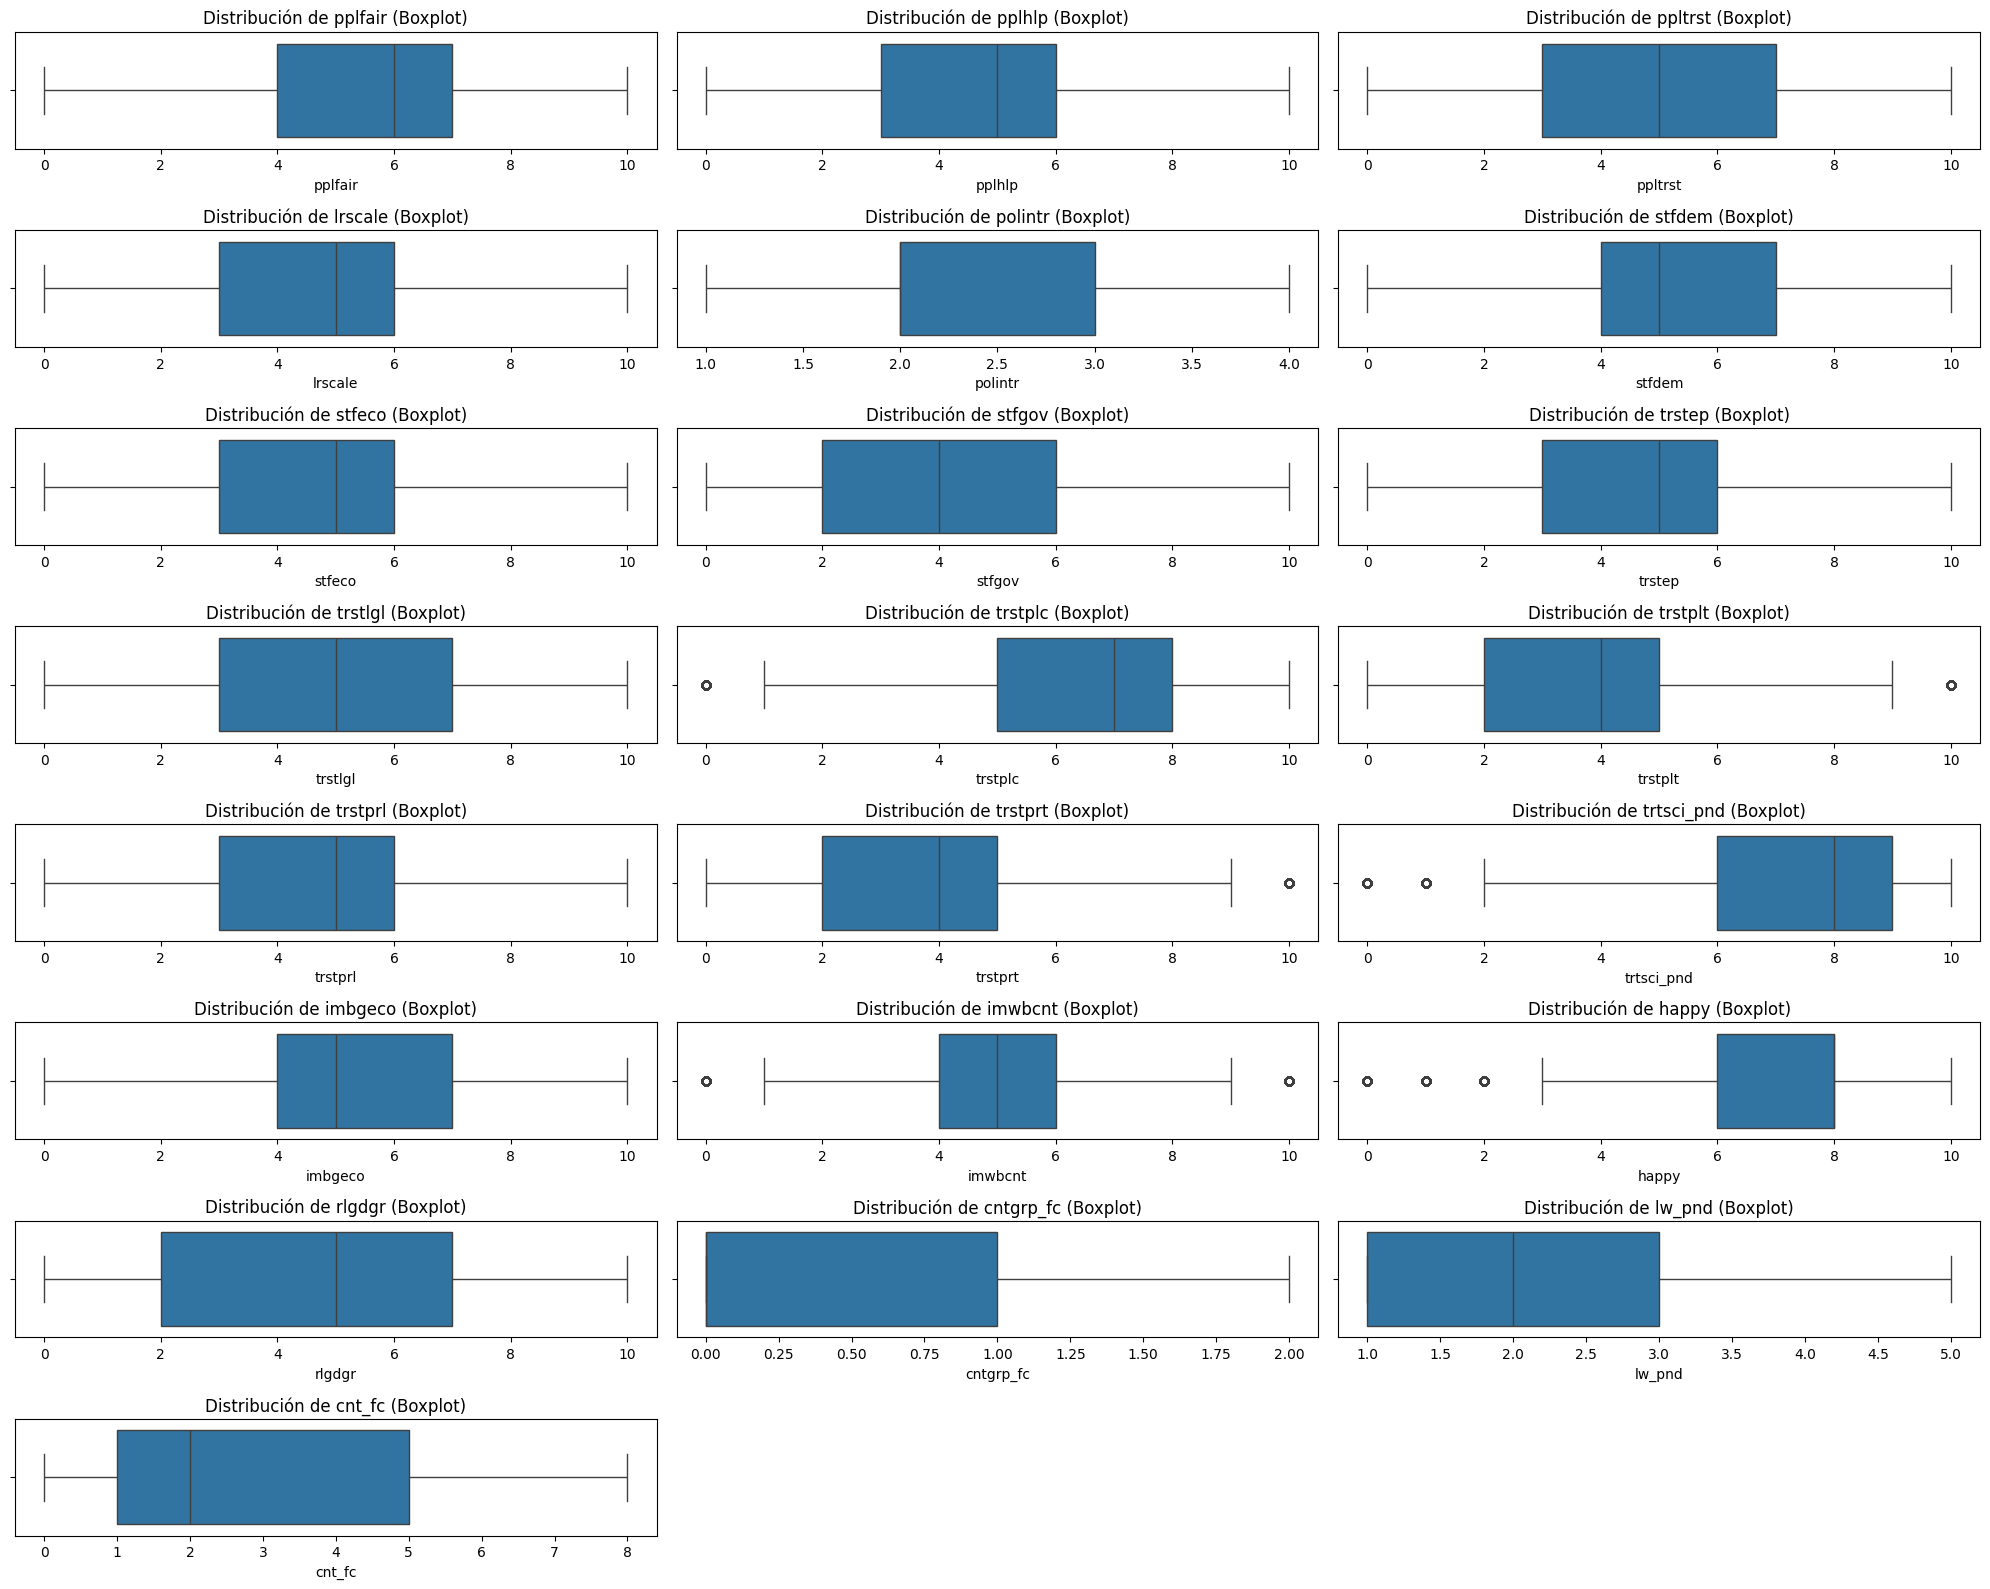

In [ ]:

def unibox3(df):
    columnas_numericas = df.select_dtypes(include=['number']).columns
    num_columnas = len(columnas_numericas)
    num_filas = (num_columnas + 2) // 3
    fig, axes = plt.subplots(num_filas, 3, figsize=(20, 2 * num_filas))

    for i, columna in enumerate(columnas_numericas):
        fila = i // 3
        columna_subplot = i % 3

        if num_filas > 1:
            ax = axes[fila, columna_subplot]
        else:
            ax = axes[columna_subplot]

        
        sns.boxplot(x=df[columna], ax=ax)
        ax.set_title(f'Distribución de {columna} (Boxplot)')

    if num_columnas % 3 != 0 and num_filas > 1:
        for j in range(num_columnas % 3, 3):
            axes[num_filas - 1, j].set_visible(False)

    plt.tight_layout()
    plt.show()
unibox3(df_eda)

In [ ]:
df_eda.describe()

,pplfair,pplhlp,ppltrst,lrscale,polintr,stfdem,stfeco,stfgov,trstep,trstlgl,...,trstprl,trstprt,trtsci_pnd,imbgeco,imwbcnt,happy,rlgdgr,cntgrp_fc,lw_pnd,cnt_fc
count,128563.0,128563.0,128563.0,128563.0,128563.0,128563.0,128563.0,128563.0,128563.0,128563.0,...,128563.0,128563.0,128563.0,128563.0,128563.0,128563.0,128563.0,128563.0,86681.0,128563.0
mean,5.563871,4.743239,4.931007,4.862908,2.509532,5.159152,4.550018,4.165732,4.604326,5.072727,...,4.503146,3.548906,7.076616,5.09183,4.888887,7.315168,4.543687,0.664064,2.087239,3.124274
std,2.180197,2.210941,2.335035,2.192461,0.895746,2.393404,2.373305,2.386024,2.394871,2.569393,...,2.464299,2.353181,2.134437,2.414123,2.225492,1.837947,3.061553,0.749254,0.984046,2.540752
min,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
25%,4.0,3.0,3.0,3.0,2.0,4.0,3.0,2.0,3.0,3.0,...,3.0,2.0,6.0,4.0,4.0,6.0,2.0,0.0,1.0,1.0
50%,6.0,5.0,5.0,5.0,2.0,5.0,5.0,4.0,5.0,5.0,...,5.0,4.0,8.0,5.0,5.0,8.0,5.0,0.0,2.0,2.0
75%,7.0,6.0,7.0,6.0,3.0,7.0,6.0,6.0,6.0,7.0,...,6.0,5.0,9.0,7.0,6.0,8.0,7.0,1.0,3.0,5.0
max,10.0,10.0,10.0,10.0,4.0,10.0,10.0,10.0,10.0,10.0,...,10.0,10.0,10.0,10.0,10.0,10.0,10.0,2.0,5.0,8.0


CONLUSIONES DEL ANALISIS UNIVARIABLE.
-TODAS NUESTRAS VARIABLES SON NUMERICAS DISCONTINUAS, Y SOLO DOS, CNTGRP_FC Y CNT_FC SON CATEGORICAS FACTORIZADAS. EN el caso de las numericas discontinuas son escalas de 0 a 10 o 1 a 4 donde el paso de un valor a otro es de 1.
-Ya hemos hablado detalladamente en el paso 4 sobre las distribuciones de las variables pero podemos observar como este dataset no contiene valores atipicos ni datos faltantes.
-Ademas gracias al diagrama de cajas podemos observar distribuciones normales similares en muchas de las variables, habiendo dos grandes grupos predominantes. Las distribuciones normales simetricas unimodales y las funciones
simetricas bimodales. Aunque estas ultimas no presentan mucha dispersion ni distancia entre los dos grupos principales de muestras.
-Muchas de las variables que presentan bimodalidad o dispersion sin tener una clase mayoritaria definida, son las que los subgrupos de paises afectan a los valores de las muestras.
-Por lo que seria interesante hacer un modelo de clasificacion/regresion para cada subconjunto.
-Se observa mucho desbalance respecto el grupo 0 de paises al resto, muchas mas muestras que el resto.

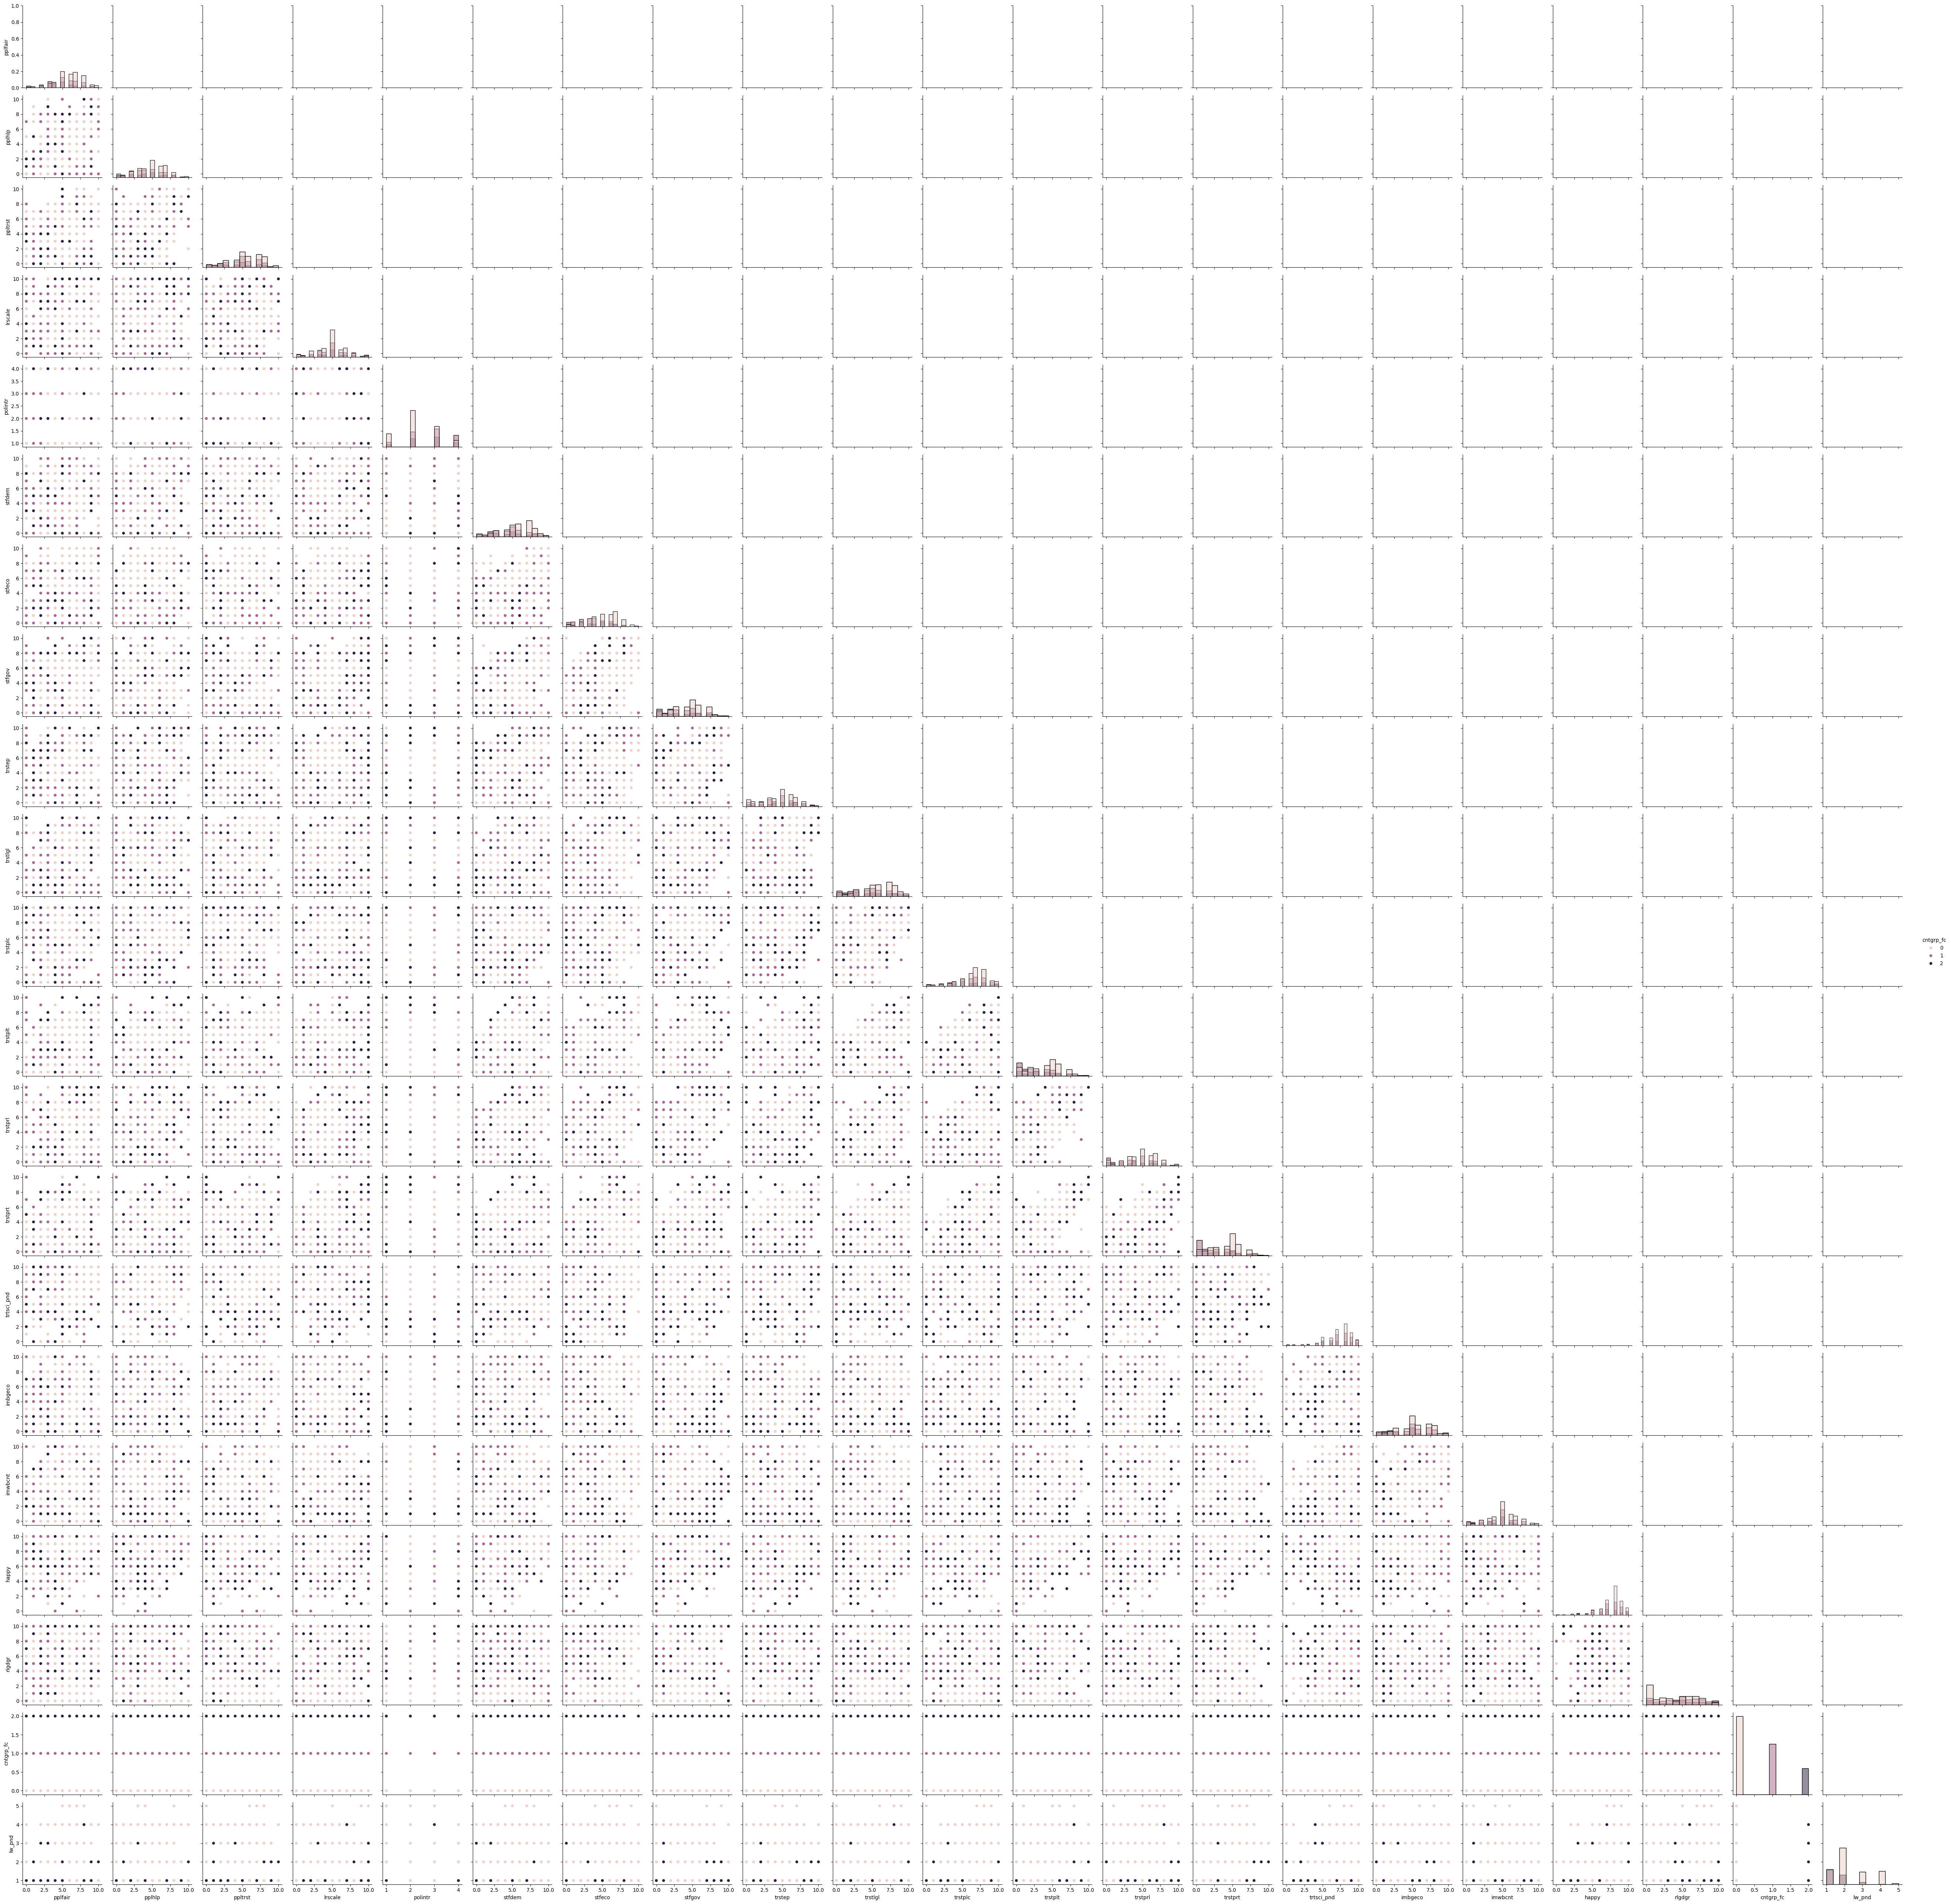

In [ ]:
#Analisis multivariable numerico-numerico.
#Gracias a esta configuracion de pairplot podremos observar como se distribuyen las muestras entre dos variables teniendo en cuenta los rangos de valores de las mismas
#Algo parecido a como si fuera un mapa de coordenadas. Si se interpreta correctamente veremos como tienden a desplazarse las muestras entre esas dos variables, si se ven centradas querra decir que hay una distribucion muy similar
#Si se deplazan mas al eje de una de las variables significara que hay linealidad positiva o negativa en funcion a que lado del eje se desplacen las muestras
#Ademas incluiremos una modalidad de estratificacion para representar las mismas muestras de cada tipo de muestra, los puntos tendran tres colores
#Cada uno de ellos correspondera a los grupos de paises
#Al mismo tiempo el grafico nos explicara como influyen estos subgrupos de muestras en las distribuciones y relaciones entre las variables.
#Podremos confirmar una vez mas la hipotesis propuesta al principio del proyecto.
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

def pairplotstratgroups(df, color_columna='cntgrp_fc', sample_size=1000):
    train, sample_df = train_test_split(df, train_size=len(df) - sample_size, stratify=df[color_columna], random_state=42)
    numeric_cols = sample_df.select_dtypes(include='number').columns.drop('cnt_fc', errors='ignore')
    g = sns.PairGrid(sample_df, hue=color_columna, vars=numeric_cols)
    g.map_lower(sns.scatterplot)
    g.map_diag(sns.histplot)
    g.add_legend()
    for i, ax_row in enumerate(g.axes):
        for j, ax in enumerate(ax_row):
            if ax is not None:
                if i == j:  
                    ax.set_xlabel(numeric_cols[j], fontsize=10)
                else:
                    ax.set_xlabel(numeric_cols[j], fontsize=10)
                    ax.set_ylabel(numeric_cols[i], fontsize=10)
    plt.show()
pairplotstratgroups(df_eda)

CONCLUSIONES PAIRPLOT MODIFICADO: GRACIAS A ESTA CONFIGURACION DE SUBGRUPOS Y COLORES A SIMPLE VISTA YA PODEMOS OBSERVAR QUE LOS SUBCONJUNTOS DE GRUPOS DE PAISES SI ALTERAN LA RELACION DE VALORES DE LAS MUESTRAS ENTRE VARIABLES.
ADEMAS TAMBIEN APRECIAMOS EN LA DIAGONAL COMO LAS DISTRIBUCIONES SON DISTINTAS
EL COLOR MAS CLARO ES EL GRUPO DE PAISES RICOS (GRUPO 0), EL ROSADO SON LOS PAISES CON LA MEDIA DE LA UE (GRUPO 1) Y LAS MUESTRAS DE TONO OSCURO PERTENECEN A LOS PAISES ECONOMICAMENTE MENOS POTENTES.
INLUSO ESTRATIFICANDO POR POR GRUPOS DE PAISES HAY UN DESBALANCEO DE CLASES.

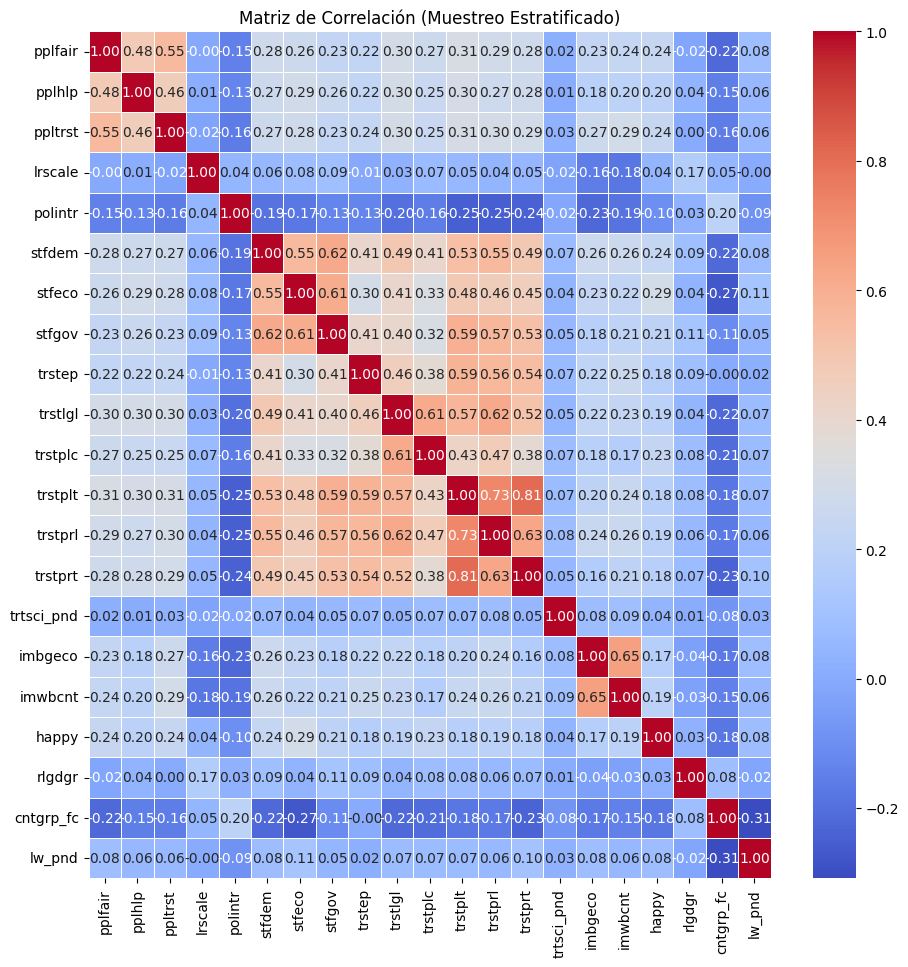

In [ ]:
#Mapa/Matriz de correlacion/calor. Utilizamos el mismo criterio que en el pairplot, la estratificacion en el desbalanceo de muestras de los diferentes grupos no afecta a la correlacion.
#Ademas de forma secuencial aplicamos un sampling para hacer el desarrollo del grafico mas ligero.
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

def heatmapstrat(df, sample_size=6000):
    train, sample_df = train_test_split(df, train_size=len(df) - sample_size, stratify=df['cntgrp_fc'], random_state=42)
    numeric_cols = sample_df.select_dtypes(include='number').columns.drop('cnt_fc', errors='ignore')
    correlation_matrix = sample_df[numeric_cols].corr()
    plt.figure(figsize=(11, 11))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Matriz de Correlación (Muestreo Estratificado)')
    plt.show()
heatmapstrat(df_eda)

CONCLUSIONES MAPA DE CALOR LINEA A LINEA.(DE IZQUIERDA A DERECHA).

21|cntrgrp_fc: variable de grupos de paises que literalmente afecta con linealidad negativa en casi todas las variables, del dataset, va a ser importante en nuestro modelo.

---------------------------------------------------------

21|lw_pnd: NO presenta ninguna correlacion lineal clara con ninguna variable excepto con cntgrp_fc, las muestras agrupadas en el grupo 1 y 2 hacen
que el valor de la variable descienda linealmente respecto al grupo 0. Indicador de que los paises pobres tienden a pensar que obedecer la ley es contraproducente.

----------------------------------------------------------

19|rlgdgr: No aporta una correlacion intervariable lineal, acordemonos que la distribucion
gaussiana inversa nos da a entender de que binarizarla y factorizarla en 0(cuando las muestras se aproximen al valor minimo de la var) o factorizarla en 1(cuando las muestras se aproximen al valor max) quiza le aporte
mas importancia al modelo y podamos descubrir sutilmente una relacion fuerte con la target.


-----------------------------------------------------------

18|happy: Esta variable tiene cierta variabilidad lineal tanto positiva como negativa,
habria que mirar la distribucion de nuevo pero si es distribucion simetrica bimodal pordria ser objetivo de 
derivarse a dos variables teniendo en cuenta los maximos locales, combinarse con otra que semanticamente y
en cuanto a la distribucion sea similar.

----------------------------------------------------------

17|imwbcnt: Esta variable tiene linealidad tanto negativa como positiva leve con muchas del dataset.
Aun asi destacamos una correlacion de 0.65 con imbgeco, sus distribuciones son similares porque la semantica de la variable hace referencia al mismo campo(inmigracion)

----------------------------------------------------------

16|imbgeco: Variable relacionada como la anterior a la inmigracion, tiene correlaciones  moderadas-leves positivas y negativas , y una alta linealidad positiva con la variable 17.

---------------------------------------------------------

15 al 9|trstsci_pnd: Variable de confianza al lobby cientifico, esta variable comparte una gran linealidad positiva con  todas las otras variables que empiezan por trst(rango de variables de la numero10 a la 15) que hacen referencia semanticamente a las variables de confianza respecto a los lobbies institucionales. Son candidatas a la combinacion y a la migracion de esta variable discreta a variable continua, es una candidata a ser otra posible variable target dado que este dataset indica que hay alta correlacion lineal entre este tipo de variables.

---------------------------------------------------------


Del 8 al 6|stfgov: Variables de escala discreta de satisfaccion respecto al govierno que guarda una correlacion lineal positiva con las demas variables del rango especificado que empiezan por stf,
semanticamente hablando son variables parecidas. Son candidatas a una combinacion entre ellas.

---------------------------------------------------------

5|polintr: Variable de escala 1 a 4 discreta que apenas aporta correlacion lineal positiva y negativa con otras variables. En funcion de su distribucion es candidata a una segmentacion o binarizacion para capturar mejores correlaciones con otras variables.

---------------------------------------------------------

4 a 2|ppltrst: Variable escala discreta que guarda una correlacion lineal positiva superior al 0.45 con otras
variables que semanticamente hacen referencia a la honestidad e interes del ciudadano de apié para con sus
relaciones sociales.

1| cntry_fc : No incluida en el estudio.

EDA ACABADO, como conlusiones del estudio de las variables, opino que se pueden capturar mejores correlaciones si se derivan o producen nuevas variables, habiendo muchas tecnicas, habra que observar las distribuciones y probar caracteristicas nuevas.
El siguiente documento estara alojado en el PASO5.1 FEATURE ENGINEERING.